The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


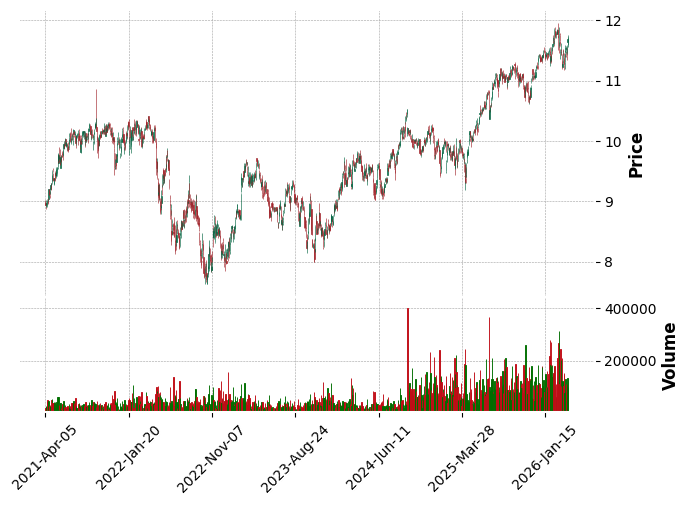

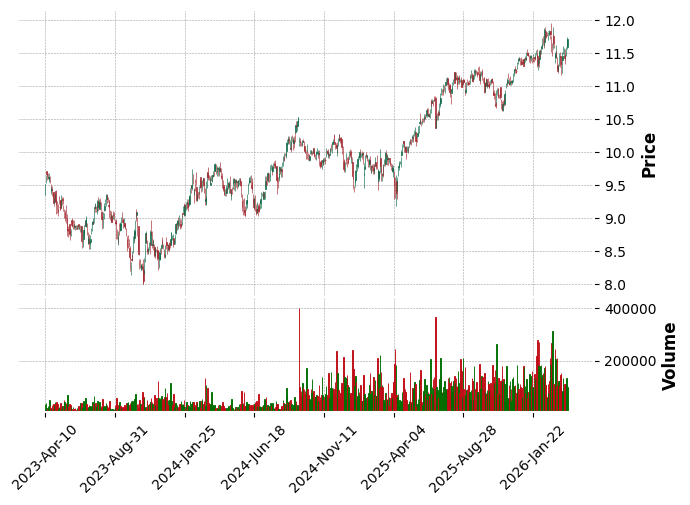

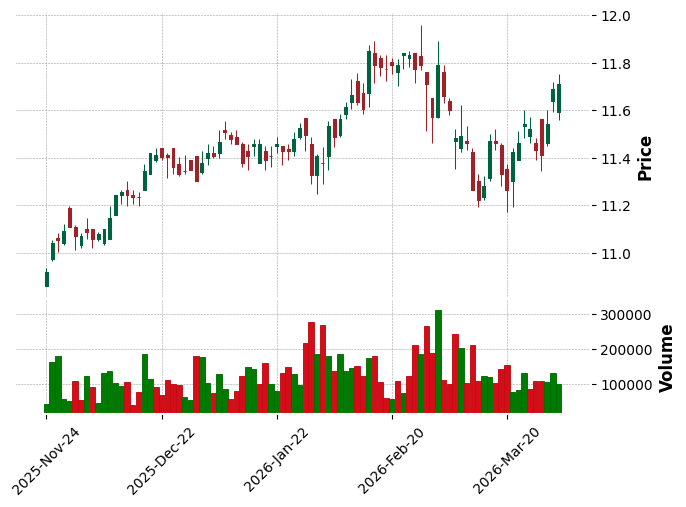

In [ ]:
%load_ext autoreload
%autoreload 1
%aimport fundamentals

import finnhub
import pandas as pd
import json
from fundamentals import Fundamentals
import numpy as np
from itables import init_notebook_mode, options
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import mplfinance as mpf
import ipynbname


init_notebook_mode(all_interactive=True)
options.style = "table-layout:auto; width:50%;"
plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup client
# ASIX
name = ipynbname.name().strip('.ipynb').upper()
thirtyday = dt.datetime.now() - dt.timedelta(days=90)
stockName = 'AI.TO'.upper()
Fun = Fundamentals(stockName)

historical = Fun.get_history()
historical.columns = historical.columns.get_level_values(0)
mpf.plot(historical, type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-750:], type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-90:], type='candle', style='charles',volume=True)

In [34]:
funds = Fun.get_fundamentals()

funds

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [35]:
#peers, avg_price = Fun.get_peers()
#print(avg_price)
#sns.barplot(x=peers.index, y=peers['Price'])
#plt.show()

In [36]:
fairValues = Fun.calculateFairValues()

fairValues.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [37]:
other_metrics = Fun.get_other_metric()

other_metrics.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [38]:
insider_sentiment = Fun.get_insider_sentiment()
print(f"{insider_sentiment[0]}:")
print("")
print(insider_sentiment[1])

insider_signal:

Moderate Insider Conviction (Insiders: 4.94%, Inst: 2.15%)


In [39]:
news = Fun.get_news()



[{'date': '2026-03-01 08:05:33',
  'headline': 'Atrium Mortgage Investment Q4 Earnings Call Highlights',
  'publisher': 'MarketBeat',
  'url': 'https://www.marketbeat.com/instant-alerts/atrium-mortgage-investment-q4-earnings-call-highlights-2026-03-01/?utm_source=yahoofinance&utm_medium=yahoofinance'}]
[{'date': '2026-03-01 08:05:33',
  'headline': 'Atrium Mortgage Investment Q4 Earnings Call Highlights',
  'publisher': 'MarketBeat',
  'url': 'https://www.marketbeat.com/instant-alerts/atrium-mortgage-investment-q4-earnings-call-highlights-2026-03-01/?utm_source=yahoofinance&utm_medium=yahoofinance'},
 {'date': '2025-08-10 13:17:42',
  'headline': 'Atrium Mortgage Investment Second Quarter 2025 Earnings: EPS: '
              'CA$0.28 (vs CA$0.26 in 2Q 2024)',
  'publisher': 'Simply Wall St.',
  'url': 'https://finance.yahoo.com/news/atrium-mortgage-investment-second-quarter-131742034.html'}]
[{'date': '2026-03-01 08:05:33',
  'headline': 'Atrium Mortgage Investment Q4 Earnings Call High

Average Weighted EPS: 0.2611
Lower Standard Deviation: 0.2533
Upper Standard Deviation: 0.2689
Total Debt/Total Equity Ratio: 0.68


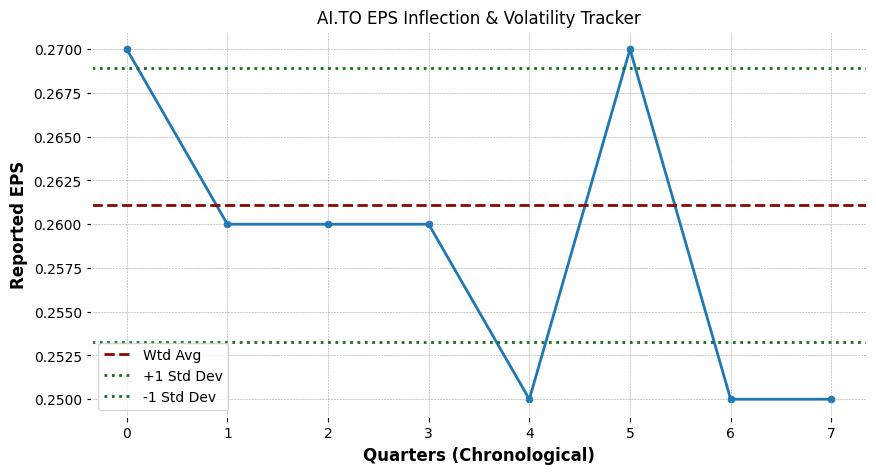

In [40]:
try:
    inflect = Fun.get_inflections()
except:
    pass

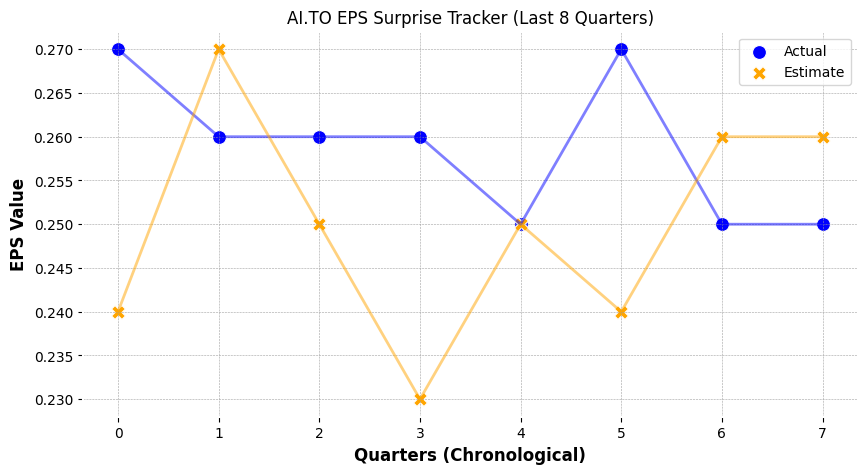

In [41]:
surprise = Fun.eps_surprise()

Revenue Trend: [50126000. 64186000. 62724000. 55830000.]


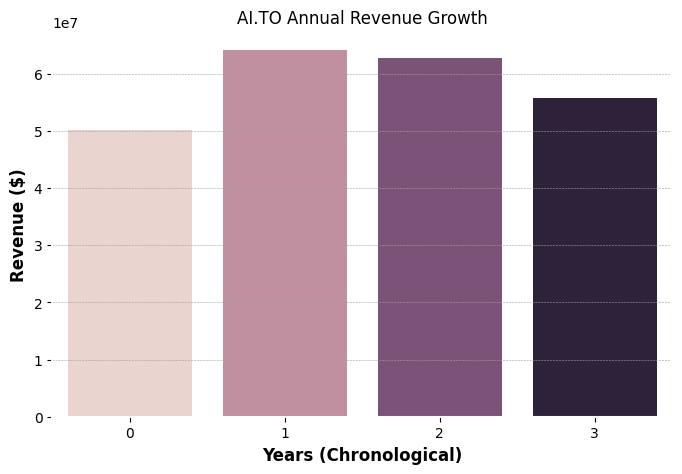

In [42]:
revenue = Fun.revenue_growth()

In [43]:
dcf = Fun.calculate_dcf()

--- Profitability Analysis: AI.TO ---

Annual Net Income History:
2021-12-31           NaN
2022-12-31   46332000.00
2023-12-31   51485000.00
2024-12-31   47852000.00
2025-12-31   49065000.00
Name: Net Income, dtype: float64

Last 4 Quarters Net Income:
2025-03-31   11901000.00
2025-06-30   13113000.00
2025-09-30   11900000.00
2025-12-31   12151000.00
Name: Net Income, dtype: float64


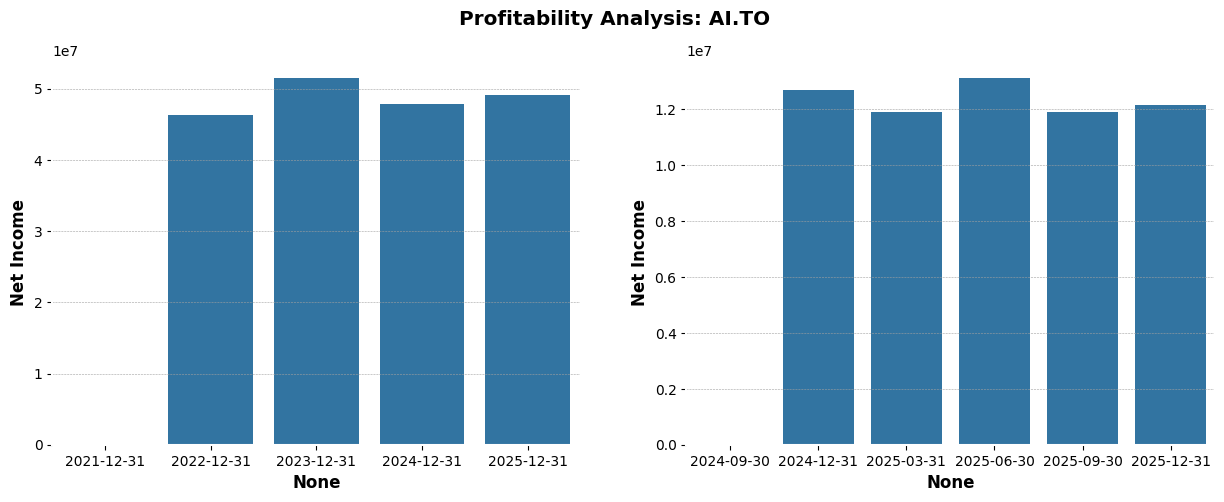

(2021-12-31           NaN
 2022-12-31   46332000.00
 2023-12-31   51485000.00
 2024-12-31   47852000.00
 2025-12-31   49065000.00
 Name: Net Income, dtype: float64,
 2024-09-30           NaN
 2024-12-31   12677000.00
 2025-03-31   11901000.00
 2025-06-30   13113000.00
 2025-09-30   11900000.00
 2025-12-31   12151000.00
 Name: Net Income, dtype: float64)

In [44]:
Fun.check_profitability()

--- FCF Analysis for AI.TO ---

Annual FCF Trend:
2021-12-31           NaN
2022-12-31   58070000.00
2023-12-31   34871000.00
2024-12-31   68128000.00
2025-12-31   17363000.00
Name: Free Cash Flow, dtype: float64


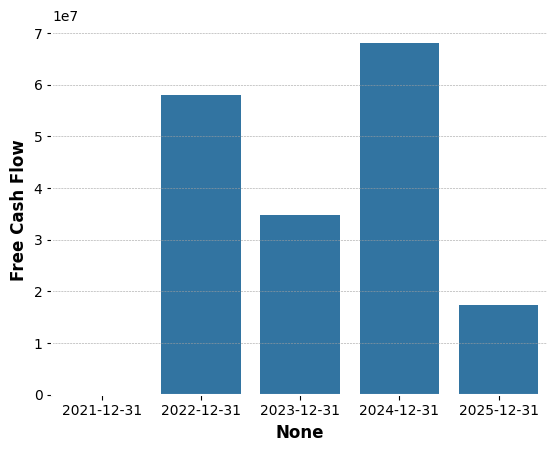

Annual Direction: DECREASING (-50,765,000)

Quarterly FCF Trend (Last 4 Quarters):
2025-03-31    24204000.00
2025-06-30   -37404000.00
2025-09-30    17389000.00
2025-12-31    13174000.00
Name: Free Cash Flow, dtype: float64


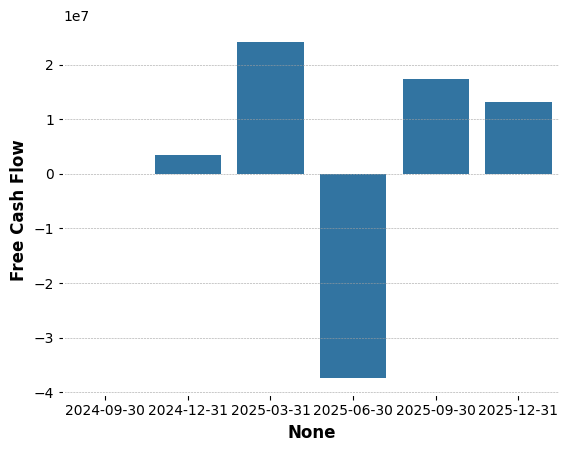

Recent Quarterly Direction: DECREASING (-4,215,000)


In [45]:
Fun.check_fcf_trend()

In [46]:
import os
import subprocess
import time
import shutil

# 1. Setup
stock_name = "AI.TO"  # Dynamically set this
new_name = f"Stock_Analysis_{stock_name}.html"
export_dir = "exports"

# 2. Run the export
print(f"Exporting {new_name} in Dark Mode...")
result = subprocess.run([
    'jupyter', 'nbconvert', 
    '--to', 'html',
    '--no-input', 
    'main.ipynb',
    '--theme', 'dark',  # Separate these into two strings
    '--output', new_name
], capture_output=True, text=True)

# 3. Create directory
if not os.path.exists(export_dir):
    os.makedirs(export_dir)

source_path = os.path.abspath(new_name)
dest_path = os.path.abspath(os.path.join(export_dir, new_name))

if os.path.exists(source_path):
    try:
        # We use copy2 then remove instead of move to bypass the lock
        shutil.copy2(source_path, dest_path)
        
        # Now we try to remove the original. 
        # If it's still locked, we just tell the user where it is.
        try:
            os.remove(source_path)
            print(f"✅ Success! Report moved to: {export_dir}/{new_name}")
        except PermissionError:
            print(f"⚠️ Report copied to {export_dir}, but original is still locked by Jupyter. You can delete '{new_name}' manually later.")
            
    except Exception as e:
        print(f"❌ Failed to copy file: {e}")
else:
    print(f"❌ Error: {new_name} was not found after export.")
    print("Nbconvert Output:", result.stderr)

Exporting Stock_Analysis_AI.TO.html in Dark Mode...
✅ Success! Report moved to: exports/Stock_Analysis_AI.TO.html


In [47]:
import os

def update_base_index(export_folder="exports"):
    if not os.path.exists(export_folder):
        print(f"⚠️ {export_folder} folder not found.")
        return

    files = [f for f in os.listdir(export_folder) if f.endswith('.html') and f != 'index.html']
    files.sort(key=lambda x: os.path.getmtime(os.path.join(export_folder, x)), reverse=True)

    links_html = "".join([
        f'<a class="report-link" href="{export_folder}/{f}">'
        f'{f.replace("Stock_Analysis_", "").replace(".html", "")}</a>' 
        for f in files
    ])

    html_content = f"""
    <!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="UTF-8">
        <title>Stock Analysis Archive</title>
        <style>
            body {{ font-family: sans-serif; background: #121212; color: #e0e0e0; padding: 40px; }}
            .container {{ max-width: 800px; margin: auto; }}
            h1 {{ border-bottom: 2px solid #333; padding-bottom: 10px; }}
            .report-link {{ 
                display: block; background: #1e1e1e; margin: 10px 0; padding: 15px; 
                border-radius: 8px; text-decoration: none; color: #4db8ff; border: 1px solid #333;
            }}
            .disclaimer {{ 
                margin-top: 50px; padding: 20px; border-top: 1px solid #333; 
                font-size: 0.85em; color: #888; line-height: 1.5;
            }}
        </style>
    </head>
    <body>
        <div class="container">
            <h1>📊 Stock Analysis Archive</h1>
            {links_html if links_html else '<p>No reports found.</p>'}
            
            <div class="disclaimer">
                <strong>Disclaimer:</strong> This report is for informational purposes only and 
                does not constitute financial advice. The data and intrinsic value calculations 
                provided are based on historical metrics and projections that may not reflect 
                future performance. Always conduct your own research before investing.
            </div>
        </div>
    </body>
    </html>
    """

    with open("index.html", "w", encoding="utf-8") as f:
        f.write(html_content)
    print(f"✅ Dashboard updated with {len(files)} reports and disclaimer.")

update_base_index()

✅ Dashboard updated with 1 reports and disclaimer.
